### Transformer -> GPT-1 변경사항

GPT-1 모델은 기존 Transformer 아키텍처를 기반으로 하지만, 비지도 사전 학습(Unsupervised Pre-training)과 생성 모델(Generative Model)의 목적에 맞춰 구조적 변경이 이루어짐

1. Encoder-Decoder에서 Decoder-Only로 변경

    앞선 단어들을 바탕으로 다음 토큰을 예측하는 언어 모델링(Language Modeling)이 목표이므로, Encoder를 완전히 제거하고 Decoder 블록만 수직으로 적층하여 사용하는 Decoder-only 구조를 채택

2. 디코더 내부 구조: Encoder-Decoder Attention(Cross-Attention) 제거

    인코더가 존재하지 않으므로 인코더의 출력을 참조하는 Cross-Attention 레이어를 삭제. 

3. 위치 정보 임베딩: 고정 함수에서 학습 가능한 임베딩(Learned Embedding)으로 변경

    Transformer는 사인(sin) 및 코사인(cos) 함수를 이용한 고정된 방식의 Positional Encoding을 사용. 그러나, GPT-1은 위치 정보를 모델이 데이터로부터 직접 학습할 수 있도록 Learned Positional Embedding을 사용. nn.Embedding(max_pos, d_model)을 사용하여 위치 인덱스 시퀀스로부터 위치별 임베딩 벡터를 Lookup Table을 통해 가져오는 방식으로 구현

4. 활성화 함수: ReLU에서 GELU로 변경

    정규화(Regularization) 효과와 비선형성(Non-linearity)을 동시에 고려하여 더 부드러운 형태의 GELU (Gaussian Error Linear Unit)를 활성화 함수 사용.

5. 데이터 전처리 및 입력 방식: 단일 시퀀스(Single Sequence) 병합

    모든 입력을 하나의 연속된 시퀀스로 처리합니다. GPT-1의 Pre-training 과정에서는 Question과 Answer를 하나로 합쳐 데이터셋을 구축합니다. 또한 Task-specific input transformations에 따라 [Start] + 질문 + [Delim] + 답변 + [Extract] 형태처럼 특수 구분자를 사용해 단일 시퀀스로 변환하여 입력

### 1. 데이터 불러오기 및 전처리

In [ ]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
!pip install torchinfo
!pip install sentencepiece

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('ChatbotData.csv')

In [39]:
def preprocess_sentence(sentence):
    # 1. 양쪽 공백 제거
    sentence = sentence.strip()

    # 2. 단어와 구두점(?.!,) 사이의 거리를 만듭니다.
    # 한글 뒤에 바로 붙은 마침표 등을 분리합니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 3. 한글(가-힣), 자음(ㄱ-ㅎ), 모음(ㅏ-ㅣ), 알파벳, 숫자, 그리고 주요 구두점을 제외한 
    # 모든 문자를 공백 ' '으로 대체합니다.
    # (특수기호나 이모지 등을 제거하는 역할)
    sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣0-9?.!, ]+", " ", sentence)
    
    # 4. 다시 한번 양쪽 공백 제거
    sentence = sentence.strip()
    return sentence

In [40]:
# 질문(Q) 전처리
questions = []
for sentence in df['Q']:
    questions.append(preprocess_sentence(sentence))

# 답변(A) 전처리
answers = []
for sentence in df['A']:
    answers.append(preprocess_sentence(sentence))

In [41]:
df['combined'] = df['Q'] + " " + df['A']
data = df['combined'].tolist()

In [42]:
data[:5]

['12시 땡! 하루가 또 가네요.',
 '1지망 학교 떨어졌어 위로해 드립니다.',
 '3박4일 놀러가고 싶다 여행은 언제나 좋죠.',
 '3박4일 정도 놀러가고 싶다 여행은 언제나 좋죠.',
 'PPL 심하네 눈살이 찌푸려지죠.']

### 2. Tokenizer (SentencePiece)

5. 데이터 전처리 및 입력 방식: 단일 시퀀스(Single Sequence) 병합

In [ ]:
corpus_file = "chatbot_corpus.txt"

with open(corpus_file, 'w', encoding='utf-8') as f:
    # 질문과 답변을 번갈아 가며 한 줄씩 기록
    for q, a in zip(questions, answers):
        f.write(q + "\n")
        f.write(a + "\n")

spm.SentencePieceTrainer.Train(
    input=corpus_file,
    model_prefix="korean_spm",
    vocab_size=8000,
    character_coverage=1.0,
    model_type="bpe",
    max_sentence_length=999999,
    bos_id=1,  # <s> (Beginning of Sentence) 설정
    eos_id=2,  # </s> (End of Sentence) 설정
    pad_id=0,  # Padding ID 설정
    unk_id=3   # Unknown Token ID 설정
)

import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.Load('korean_spm.model')

In [44]:
import sentencepiece as spm

sp = spm.SentencePieceProcessor()
sp.Load('korean_spm.model')

True

In [45]:
sentence = "나는 점심을 10분전에 먹어서 매우 졸려.."

sentence = preprocess_sentence(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 나는 점심을 10분전에 먹어서 매우 졸려 . .
Tokenized: ['▁나는', '▁점심', '을', '▁10', '분', '전에', '▁먹어', '서', '▁매', '우', '▁졸려', '▁.', '▁.']
Encoded: [688, 1823, 6797, 1523, 6905, 2521, 747, 6821, 348, 6914, 2104, 4, 4]
Decoded: 나는 점심을 10분전에 먹어서 매우 졸려 . .


In [46]:
sentence_len = [len(sp.EncodeAsIds(q + " " + a)) for q, a in zip(questions, answers)]

# 2. 통계치 출력
print('전체 시퀀스 최소 길이 : {}'.format(np.min(sentence_len)))
print('전체 시퀀스 최대 길이 : {}'.format(np.max(sentence_len)))
print('전체 시퀀스 평균 길이 : {:.2f}'.format(np.mean(sentence_len)))
print('전체 시퀀스 표준 편차 : {:.2f}'.format(np.std(sentence_len)))

전체 시퀀스 최소 길이 : 2
전체 시퀀스 최대 길이 : 40
전체 시퀀스 평균 길이 : 11.18
전체 시퀀스 표준 편차 : 3.81


In [47]:
class chatbot(Dataset):
    def __init__(self, data, sp, max_length=40):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in zip(questions, answers):
            # 1) 토크나이즈
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) 스페셜 토큰 ID 설정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2
            sep_id = 4 # 질문과 답변을 구분할 Delimiter (임의의 값이나 spm 추가 토큰)

            # 3) GPT-1 핵심: 질문과 답변을 하나로 결합 (<s> Q <sep> A </s>)
            # 기존 q_tokens, a_tokens 대신 하나로 통합된 tokens를 생성합니다.
            combined_tokens = [bos_id] + q_ids + [sep_id] + a_ids + [eos_id]

            # 4) 길이 제한 및 패딩
            if len(combined_tokens) > max_length:
                continue
                
            combined_tokens += [0] * (max_length - len(combined_tokens))

            # 5) GPT-1의 학습 목표: Next Token Prediction
            # 입력(input): 마지막 토큰을 제외한 [0 : max-1]
            # 타겟(target): 첫 토큰을 제외한 [1 : max] (한 칸씩 밀린 형태)
            dec_input = combined_tokens[:-1]
            target = combined_tokens[1:]

            self.data.append({
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        # GPT-1은 enc_input이 없으므로 dec_input과 target만 반환합니다.
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return dec_input, target

In [48]:
dataset = chatbot(data, sp, max_length=40)

In [49]:
for decoder_input, decoder_label in dataset:
    print("텐서 크기 :", decoder_input.size())
    
    print("\n--- Decoder Input (모델 입력) ---")
    print(decoder_input)
    # [:-1] 등으로 패딩 전까지의 텍스트를 깔끔하게 보기 위해 0(pad)을 제외하고 디코딩할 수 있습니다.
    print(sp.decode(decoder_input.tolist()))
    
    print("\n--- Decoder Label (예측 정답) ---")
    print(decoder_label)
    print(sp.decode(decoder_label.tolist()))
    break

텐서 크기 : torch.Size([39])

--- Decoder Input (모델 입력) ---
tensor([   1, 5554, 6825, 3202,  108,    4, 4484,  214, 5921,    4,    2,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
12시 땡 ! . 하루가 또 가네요 .

--- Decoder Label (예측 정답) ---
tensor([5554, 6825, 3202,  108,    4, 4484,  214, 5921,    4,    2,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0])
12시 땡 ! . 하루가 또 가네요 .


#### 데이터로더 구성

In [50]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for decoder_input, decoder_label in dataloader:
    print("Decoder Input 크기 (Batch, Seq_len):", decoder_input.size())
    print("Decoder Label 크기 (Batch, Seq_len):", decoder_label.size())
    break

Decoder Input 크기 (Batch, Seq_len): torch.Size([32, 39])
Decoder Label 크기 (Batch, Seq_len): torch.Size([32, 39])


### 3. GPT-1 모델 아키텍처 구성

아키텍처 정의

~~Positional Encoding~~

MultiHead Attention

Masking
- padding mask
- Look-Ahead mask

~~Encoder~~

Decoder

#### MultiHead Attention

In [51]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


#### Masking

#### padding mask

In [52]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask

#### Look-ahead mask

In [53]:
def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

#### Decoder

1. Encoder-Decoder에서 Decoder-Only로 변경

2. 디코더 내부 구조: Encoder-Decoder Attention(Cross-Attention) 제거

In [54]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [55]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

### 4. GPT-1 모델 정의

3. 위치 정보 임베딩: 고정 함수에서 학습 가능한 임베딩(Learned Embedding)으로 변경

4. 활성화 함수: ReLU에서 GELU로 변경

In [56]:
class GPTLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(GPTLayer, self).__init__()

        # 1. Masked Self-Attention
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 2. Feed Forward Network
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(), # GPT-1은 ReLU 대신 GELU를 주로 사용
            nn.Linear(ff_dim, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # GPT는 Look-ahead mask만 사용함
        # 1) Masked Self-Attention
        attn_out = self.self_mha(x, x, x, mask=mask)
        attn_out = self.dropout1(attn_out)
        out1 = self.norm1(x + attn_out)

        # 2) Feed Forward
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)

        return out2

In [57]:
class GPT1(nn.Module):
    def __init__(self,
                 vocab_size,
                 max_pos,      # 최대 시퀀스 길이
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(GPT1, self).__init__()

        self.d_model = d_model

        # (1) Embedding
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) Learned Positional Embedding
        self.pos_embedding = nn.Embedding(max_pos, d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) GPT Layers (Decoder-only)
        self.layers = nn.ModuleList([
            GPTLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        # (4) Final Output Layer
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()

        # 1) 포지션 정보 생성 (0, 1, 2, ..., seq_len-1)
        pos = torch.arange(0, seq_len).expand(batch_size, seq_len).to(x.device)

        # 2) Token Embedding + Positional Embedding
        x = self.embedding(x) + self.pos_embedding(pos)
        x = self.dropout(x)

        # 3) Look-ahead Mask 생성 (현재 위치 이후를 보지 못하게 함)
        mask = self.create_look_ahead_mask(seq_len).to(x.device)

        # 4) GPT Layers 통과
        for layer in self.layers:
            x = layer(x, mask=mask)

        # 5) Next Token Prediction을 위한 Logits 출력
        logits = self.final_linear(x)
        return logits

    def create_look_ahead_mask(self, size):
        # 상삼각 행렬을 이용해 자기 자신보다 미래의 토큰을 마스킹
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        return mask # (seq_len, seq_len)

In [58]:
# 하이퍼파라미터 설정
NUM_LAYERS = 2     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 512        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)
MAX_POS = 512 

# 모델 생성
model = GPT1(
    vocab_size=VOCAB_SIZE,
    max_pos=MAX_POS,
    num_layers=NUM_LAYERS,
    ff_dim=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

GPT1(
  (embedding): Embedding(8000, 256)
  (pos_embedding): Embedding(512, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-1): 2 x GPTLayer(
      (self_mha): MultiHeadAttention(
        (query_dense): Linear(in_features=256, out_features=256, bias=True)
        (key_dense): Linear(in_features=256, out_features=256, bias=True)
        (value_dense): Linear(in_features=256, out_features=256, bias=True)
        (out_dense): Linear(in_features=256, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (final_linear): Linear(in_featur

#### model.summary()

In [59]:
from torchinfo import summary

summary(model, input_size=(1, 512), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
GPT1                                     [1, 512, 8000]            --
├─Embedding: 1-1                         [1, 512, 256]             2,048,000
├─Embedding: 1-2                         [1, 512, 256]             131,072
├─Dropout: 1-3                           [1, 512, 256]             --
├─ModuleList: 1-4                        --                        --
│    └─GPTLayer: 2-1                     [1, 512, 256]             --
│    │    └─MultiHeadAttention: 3-1      [1, 512, 256]             263,168
│    │    └─Dropout: 3-2                 [1, 512, 256]             --
│    │    └─LayerNorm: 3-3               [1, 512, 256]             512
│    │    └─Sequential: 3-4              [1, 512, 256]             262,912
│    │    └─Dropout: 3-5                 [1, 512, 256]             --
│    │    └─LayerNorm: 3-6               [1, 512, 256]             512
│    └─GPTLayer: 2-2                     [1, 512, 256]       

#### 손실함수

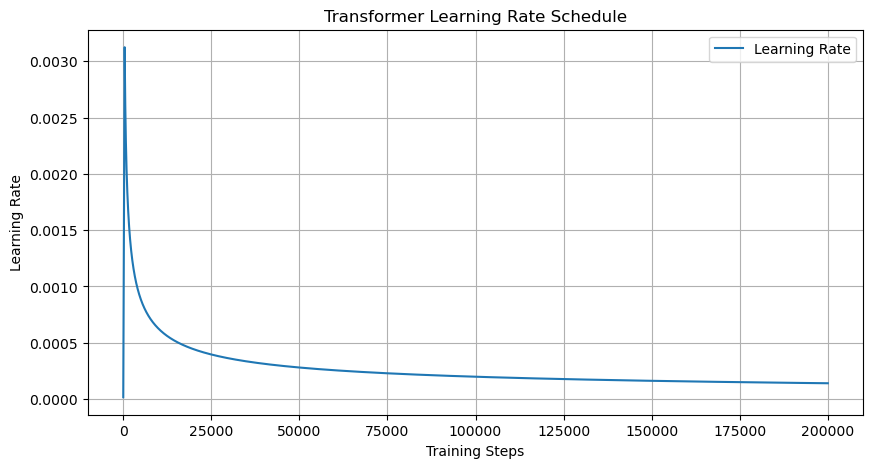

In [60]:
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())

#### learning rate

def get_lr_lambda(d_model, warmup_steps=400):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# 하이퍼파라미터 설정
d_model = 256
warmup_steps = 400
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

#### 모델 컴파일

In [61]:
# Optimizer 정의
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9, lr = 1)

# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=400))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

#### 훈련하기

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [63]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(dec_input)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

#### model.fit()

In [64]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=30,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 9.1345, Acc: 0.0000
[Epoch 1, Step 100] Loss: 6.5659, Acc: 0.2462
[Epoch 1, Step 200] Loss: 6.3922, Acc: 0.2488
[Epoch 1, Step 300] Loss: 5.9959, Acc: 0.2376
Epoch 1 Completed - Avg Loss: 6.5112, Avg Acc: 0.2303
[Epoch 2, Step 0] Loss: 5.3846, Acc: 0.2587
[Epoch 2, Step 100] Loss: 5.5089, Acc: 0.2727
[Epoch 2, Step 200] Loss: 5.4942, Acc: 0.2445
[Epoch 2, Step 300] Loss: 5.3947, Acc: 0.2932
Epoch 2 Completed - Avg Loss: 5.4371, Avg Acc: 0.2712
[Epoch 3, Step 0] Loss: 4.6187, Acc: 0.2979
[Epoch 3, Step 100] Loss: 4.7670, Acc: 0.2902
[Epoch 3, Step 200] Loss: 4.5020, Acc: 0.3422
[Epoch 3, Step 300] Loss: 4.1460, Acc: 0.3341
Epoch 3 Completed - Avg Loss: 4.5289, Avg Acc: 0.3111
[Epoch 4, Step 0] Loss: 3.8994, Acc: 0.3623
[Epoch 4, Step 100] Loss: 3.8338, Acc: 0.3413
[Epoch 4, Step 200] Loss: 4.0826, Acc: 0.3151
[Epoch 4, Step 300] Loss: 4.1869, Acc: 0.3427
Epoch 4 Completed - Avg Loss: 3.9200, Avg Acc: 0.3511
[Epoch 5, Step 0] Loss: 3.0295, Acc: 0.4336
[Epoch 5, St

### 5. 챗봇 테스트해보기 (Inference)

In [65]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 40


    # 전처리
    sentence = preprocess_sentence(sentence)

    # 2. GPT-1 입력 구성: <s> + 질문 + </s>
    input_ids = [START_TOKEN] + tokenizer.EncodeAsIds(sentence) + [END_TOKEN]
    
    # 질문 부분의 길이를 저장 (나중에 출력할 때 질문은 빼고 답변만 보기 위함)
    prompt_length = len(input_ids)

    # 차원 확장: (batch_size=1, seq_len)
    dec_input = torch.tensor([input_ids], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            #dec_input 하나만 들어갑니다!
            logits = model(dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 4. 디코더 입력(dec_input) 맨 뒤에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [66]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [67]:
sentence = '안녕?'
sentence_generation(model, sentence, sp, device)

입력 : 안녕?
출력 : 안녕 ? 기대하고야겠죠 ? . 기억을 보지도 몰라요 .


'안녕 ? 기대하고야겠죠 ? . 기억을 보지도 몰라요 .'

In [68]:
sentence = '뭐해?'
sentence_generation(model, sentence, sp, device)

입력 : 뭐해?
출력 : 뭐해 ?긴 싶은데 .보 확인해보세요 .


'뭐해 ?긴 싶은데 .보 확인해보세요 .'

In [69]:
sentence = '재밌어?'
sentence_generation(model, sentence, sp, device)

입력 : 재밌어?
출력 : 재밌어 ?긴지 힘드네 . 이별을 준비하는 기간이 길 거예요 .


'재밌어 ?긴지 힘드네 . 이별을 준비하는 기간이 길 거예요 .'

마치 여자친구와 대화 잘하는 남자(?)의 대화법처럼 나온다

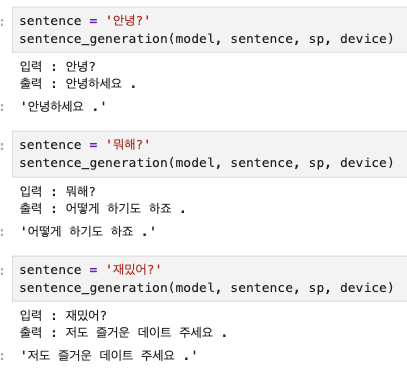

트랜스포머와 비교 했을 때는 좀 더 길게 얘기해준 것 같다